In [ ]:
#Task 4: Regression — Revenue Forecasting
"""
1. Linear Regression
2. Ridge Regression (L2)
3. Lasso Regression (L1)
4. ElasticNet
5. Decision Tree Regressor
6. Random Forest Regressor
7. Support Vector Regressor (SVR)
"""

In [ ]:
# 1. Linear Regression model


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Preparing data for Linear Regression...")

# Define features (X_reg) and target (y_reg) for regression
# We'll use the df_label_encoding as it contains numerical features and a numerical TotalCharges

# Drop non-feature columns and the target variable itself
X_reg = df_label_encoding.drop(['customerID', 'TotalCharges', 'MonthlyCharges', 'Churn'], axis=1)
y_reg = df_label_encoding['MonthlyCharges']

# Split the data into training and test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Shape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

Preparing data for Linear Regression...
Shape of X_train_reg: (4720, 17)
Shape of y_train_reg: (4720,)
Shape of X_test_reg: (1181, 17)
Shape of y_test_reg: (1181,)


In [ ]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = linear_model.predict(X_test_reg)

# Evaluate the model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test_reg, y_pred_reg)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared = 1 - (1-r_squared)*(n-1)/(n-p-1)

print("\nLinear Regression Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r_squared:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")


Linear Regression Performance on Test Set:
Mean Absolute Error (MAE): 15.6840
Mean Squared Error (MSE): 337.5056
Root Mean Squared Error (RMSE): 18.3713
R-squared (R²): 0.6393
Adjusted R-squared: 0.6340


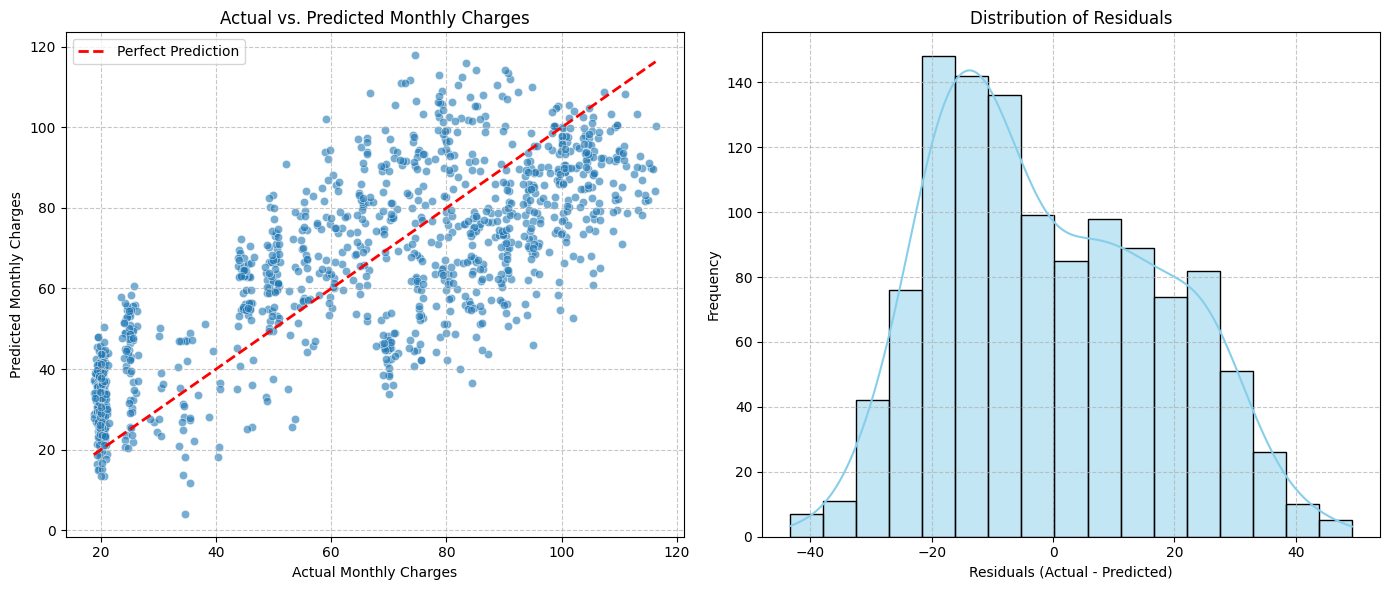

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals = y_test_reg - y_pred_reg
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='skyblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 2. Ridge Regression(L2)


from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nRidge Regression")

# Define the parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize GridSearchCV
grid_search_ridge = GridSearchCV(
    Ridge(random_state=42), # random_state for reproducibility (though Ridge is deterministic for fixed alpha)
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_ridge.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for Ridge Regression:", grid_search_ridge.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_ridge.best_score_)


Ridge Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best hyperparameters found for Ridge Regression: {'alpha': 1}
Best MSE on training set (cross-validation): 348.8999252508209


In [ ]:
# Get the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

# Make predictions on the test set with the best model
y_pred_ridge = best_ridge_model.predict(X_test_reg)

# Evaluate the tuned model
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r_squared_ridge = r2_score(y_test_reg, y_pred_ridge)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_ridge = 1 - (1-r_squared_ridge)*(n-1)/(n-p-1)

print("\nRidge Regression Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_ridge:.4f}")
print(f"Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")
print(f"R-squared (R²): {r_squared_ridge:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_ridge:.4f}")


Ridge Regression Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 15.6823
Mean Squared Error (MSE): 337.4559
Root Mean Squared Error (RMSE): 18.3700
R-squared (R²): 0.6394
Adjusted R-squared: 0.6341


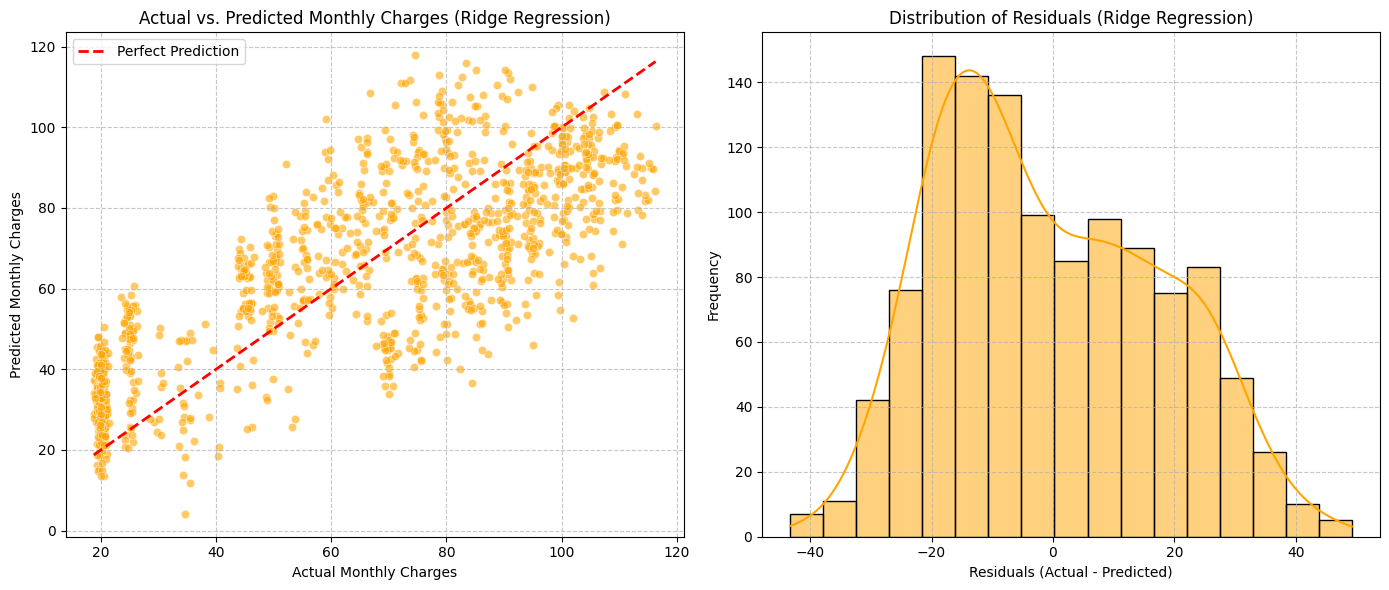

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_ridge, alpha=0.6, color='orange')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (Ridge Regression)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_ridge = y_test_reg - y_pred_ridge
plt.subplot(1, 2, 2)
sns.histplot(residuals_ridge, kde=True, color='orange')
plt.title('Distribution of Residuals (Ridge Regression)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 3. Lasso Regression(L1)


from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nLasso Regression")

# Define the parameter grid for Lasso Regression
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize GridSearchCV
grid_search_lasso = GridSearchCV(
    Lasso(random_state=42, max_iter=2000), # Increased max_iter for convergence
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lasso.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for Lasso Regression:", grid_search_lasso.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_lasso.best_score_)


Lasso Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best hyperparameters found for Lasso Regression: {'alpha': 0.01}
Best MSE on training set (cross-validation): 348.8988576779382


In [ ]:
# Get the best Lasso model
best_lasso_model = grid_search_lasso.best_estimator_

# Make predictions on the test set with the best model
y_pred_lasso = best_lasso_model.predict(X_test_reg)

# Evaluate the tuned model
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r_squared_lasso = r2_score(y_test_reg, y_pred_lasso)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_lasso = 1 - (1-r_squared_lasso)*(n-1)/(n-p-1)

print("\nLasso Regression Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_lasso:.4f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.4f}")
print(f"R-squared (R²): {r_squared_lasso:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_lasso:.4f}")


Lasso Regression Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 15.6887
Mean Squared Error (MSE): 337.4577
Root Mean Squared Error (RMSE): 18.3700
R-squared (R²): 0.6394
Adjusted R-squared: 0.6341


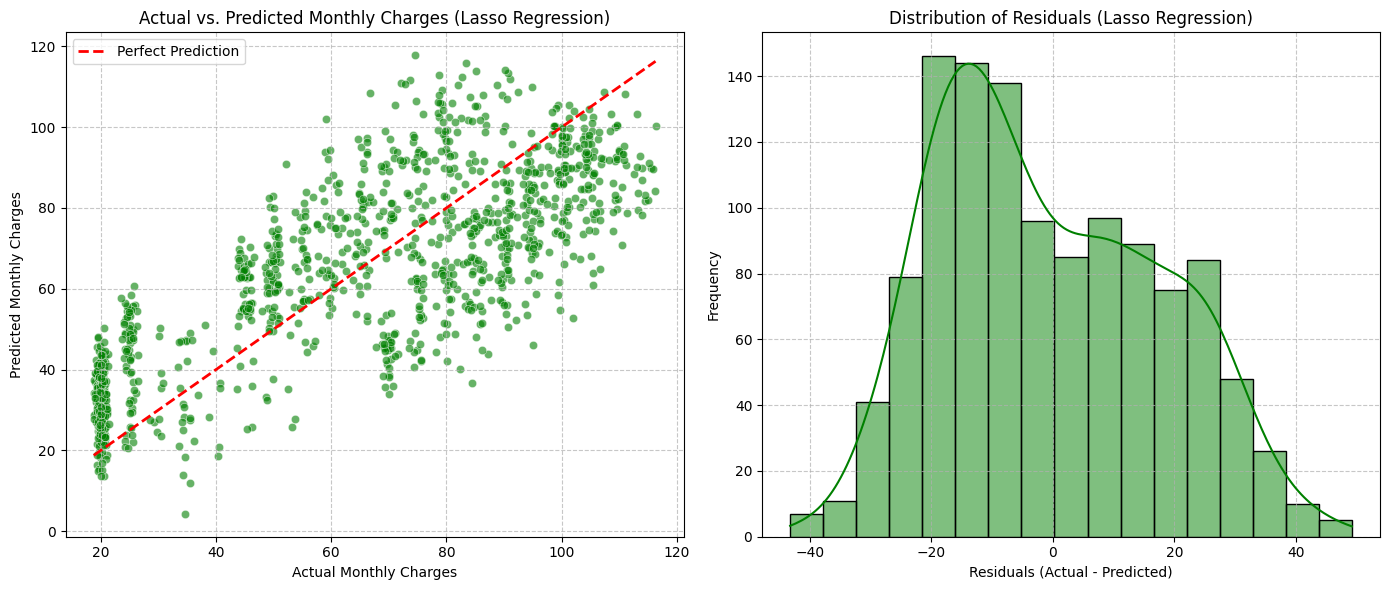

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_lasso, alpha=0.6, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (Lasso Regression)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_lasso = y_test_reg - y_pred_lasso
plt.subplot(1, 2, 2)
sns.histplot(residuals_lasso, kde=True, color='green')
plt.title('Distribution of Residuals (Lasso Regression)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 4. ElasticNet


from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nElasticNet Regression")

# Define the parameter grid for ElasticNet Regression
param_grid_elasticnet = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
}

# Initialize GridSearchCV
grid_search_elasticnet = GridSearchCV(
    ElasticNet(random_state=42, max_iter=2000), # Increased max_iter for convergence
    param_grid_elasticnet,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_elasticnet.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for ElasticNet Regression:", grid_search_elasticnet.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_elasticnet.best_score_)


ElasticNet Regression
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best hyperparameters found for ElasticNet Regression: {'alpha': 0.01, 'l1_ratio': 1}
Best MSE on training set (cross-validation): 348.8988576779382


In [ ]:
# Get the best ElasticNet model
best_elasticnet_model = grid_search_elasticnet.best_estimator_

# Make predictions on the test set with the best model
y_pred_elasticnet = best_elasticnet_model.predict(X_test_reg)

# Evaluate the tuned model
mae_elasticnet = mean_absolute_error(y_test_reg, y_pred_elasticnet)
mse_elasticnet = mean_squared_error(y_test_reg, y_pred_elasticnet)
rmse_elasticnet = np.sqrt(mse_elasticnet)
r_squared_elasticnet = r2_score(y_test_reg, y_pred_elasticnet)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_elasticnet = 1 - (1-r_squared_elasticnet)*(n-1)/(n-p-1)

print("\nElasticNet Regression Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_elasticnet:.4f}")
print(f"Mean Squared Error (MSE): {mse_elasticnet:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_elasticnet:.4f}")
print(f"R-squared (R²): {r_squared_elasticnet:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_elasticnet:.4f}")


ElasticNet Regression Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 15.6887
Mean Squared Error (MSE): 337.4577
Root Mean Squared Error (RMSE): 18.3700
R-squared (R²): 0.6394
Adjusted R-squared: 0.6341


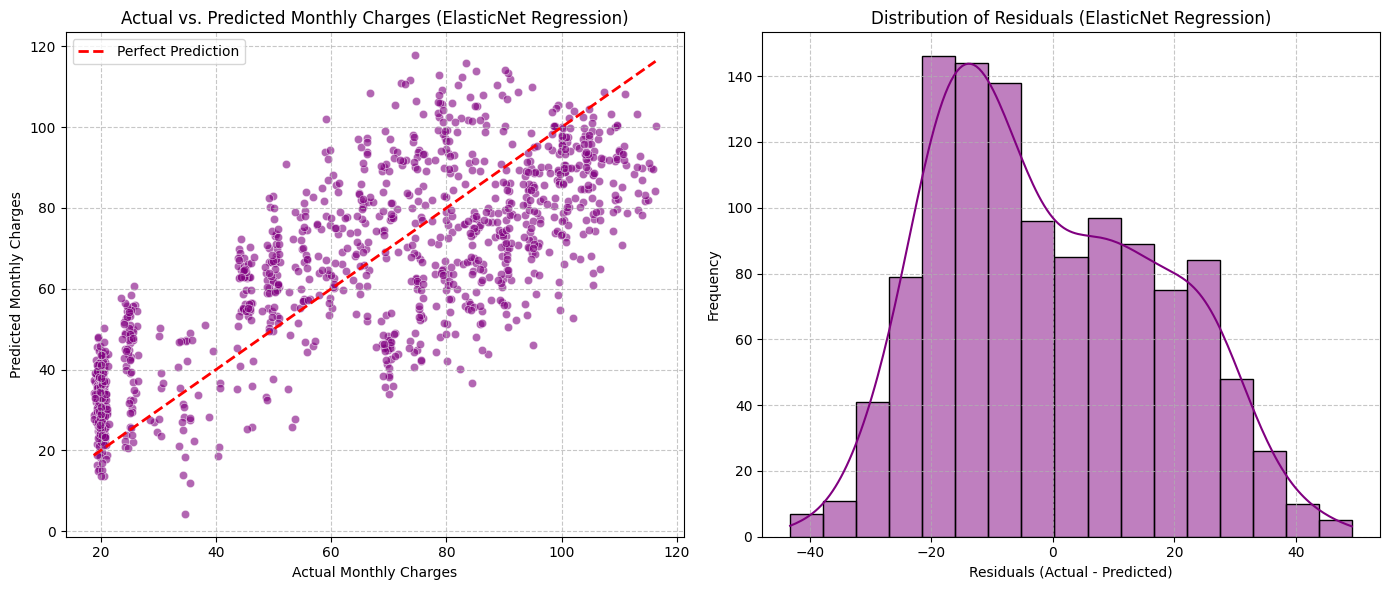

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_elasticnet, alpha=0.6, color='purple')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (ElasticNet Regression)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_elasticnet = y_test_reg - y_pred_elasticnet
plt.subplot(1, 2, 2)
sns.histplot(residuals_elasticnet, kde=True, color='purple')
plt.title('Distribution of Residuals (ElasticNet Regression)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 5. Decision Tree Regressor


from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nDecision Tree Regressor")

# Define the parameter grid for Decision Tree Regressor
param_grid_dt_reg = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree
    'min_samples_leaf': [1, 5, 10, 20], # Minimum samples required at a leaf node
    'splitter': ['best', 'random'] # Strategy used to choose the split at each node
}

# Initialize GridSearchCV
grid_search_dt_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt_reg,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_dt_reg.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for Decision Tree Regressor:", grid_search_dt_reg.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_dt_reg.best_score_)


Decision Tree Regressor
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best hyperparameters found for Decision Tree Regressor: {'max_depth': 10, 'min_samples_leaf': 1, 'splitter': 'random'}
Best MSE on training set (cross-validation): 2.089429121366574


In [ ]:
# Get the best Decision Tree Regressor model
best_dt_reg_model = grid_search_dt_reg.best_estimator_

# Make predictions on the test set with the best model
y_pred_dt_reg = best_dt_reg_model.predict(X_test_reg)

# Evaluate the tuned model
mae_dt_reg = mean_absolute_error(y_test_reg, y_pred_dt_reg)
mse_dt_reg = mean_squared_error(y_test_reg, y_pred_dt_reg)
rmse_dt_reg = np.sqrt(mse_dt_reg)
r_squared_dt_reg = r2_score(y_test_reg, y_pred_dt_reg)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_dt_reg = 1 - (1-r_squared_dt_reg)*(n-1)/(n-p-1)

print("\nDecision Tree Regressor Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_dt_reg:.4f}")
print(f"Mean Squared Error (MSE): {mse_dt_reg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt_reg:.4f}")
print(f"R-squared (R²): {r_squared_dt_reg:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_dt_reg:.4f}")


Decision Tree Regressor Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 0.9572
Mean Squared Error (MSE): 2.0064
Root Mean Squared Error (RMSE): 1.4165
R-squared (R²): 0.9979
Adjusted R-squared: 0.9978


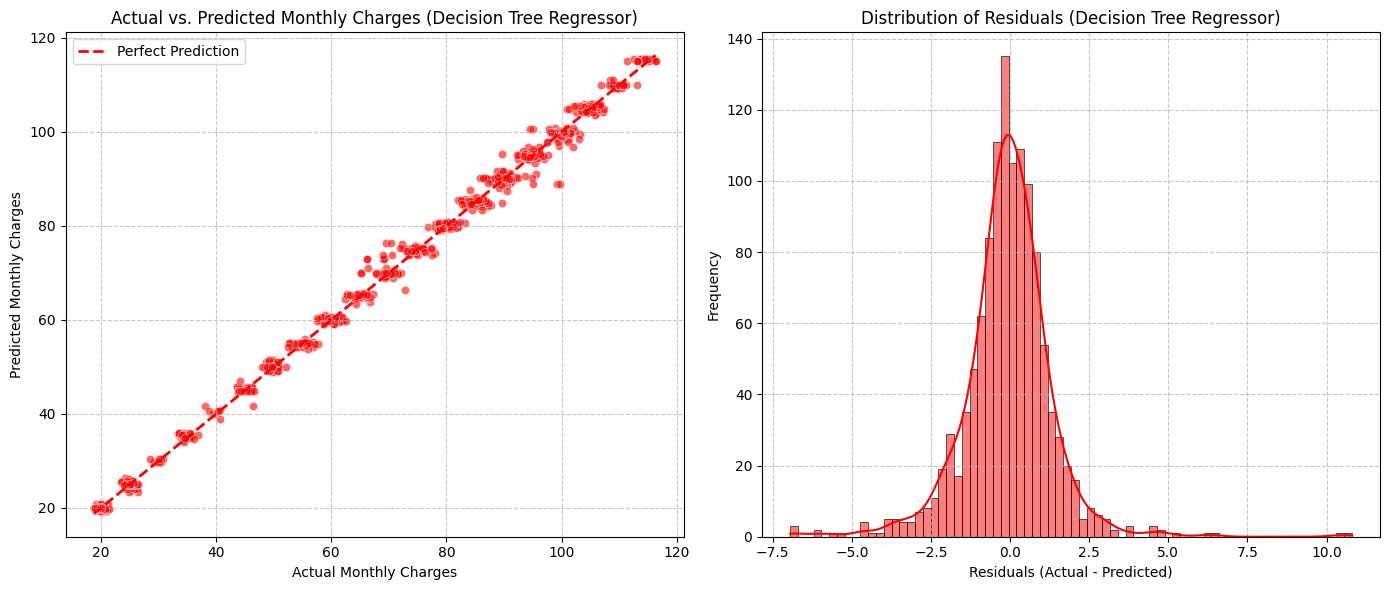

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_dt_reg, alpha=0.6, color='red')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (Decision Tree Regressor)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_dt_reg = y_test_reg - y_pred_dt_reg
plt.subplot(1, 2, 2)
sns.histplot(residuals_dt_reg, kde=True, color='red')
plt.title('Distribution of Residuals (Decision Tree Regressor)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 6. Random Forest Regressor


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nRandom Forest Regressor")

# Define the parameter grid for Random Forest Regressor
param_grid_rf_reg = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [5, 10, None], # Max depth of the tree
    'min_samples_leaf': [1, 5, 10] # Minimum samples required at a leaf node
}

# Initialize GridSearchCV
grid_search_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_reg,
    cv=3, # Using a smaller CV fold to speed up computation
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf_reg.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for Random Forest Regressor:", grid_search_rf_reg.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_rf_reg.best_score_)


Random Forest Regressor
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best hyperparameters found for Random Forest Regressor: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best MSE on training set (cross-validation): 2.331453575285311


In [ ]:
# Get the best Random Forest Regressor model
best_rf_reg_model = grid_search_rf_reg.best_estimator_

# Make predictions on the test set with the best model
y_pred_rf_reg = best_rf_reg_model.predict(X_test_reg)

# Evaluate the tuned model
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r_squared_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_rf_reg = 1 - (1-r_squared_rf_reg)*(n-1)/(n-p-1)

print("\nRandom Forest Regressor Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_rf_reg:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf_reg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_reg:.4f}")
print(f"R-squared (R²): {r_squared_rf_reg:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_rf_reg:.4f}")


Random Forest Regressor Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 0.9562
Mean Squared Error (MSE): 1.7635
Root Mean Squared Error (RMSE): 1.3280
R-squared (R²): 0.9981
Adjusted R-squared: 0.9981


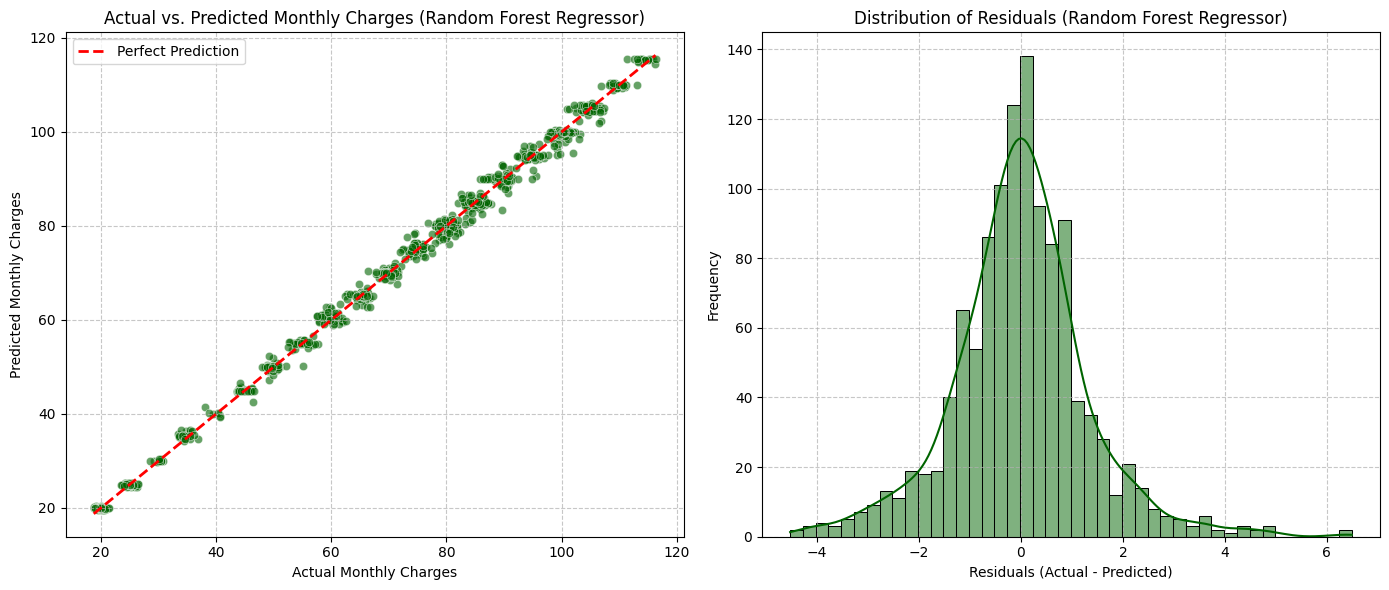

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_rf_reg, alpha=0.6, color='darkgreen')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (Random Forest Regressor)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_rf_reg = y_test_reg - y_pred_rf_reg
plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_reg, kde=True, color='darkgreen')
plt.title('Distribution of Residuals (Random Forest Regressor)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 7. Support Vector Regressor(SVR)


from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nSupport Vector Regressor (SVR)")

# Define the parameter grid for SVR
param_grid_svr = {
    'C': [0.1, 1, 10], # Regularization parameter
    'kernel': ['rbf'], # Common kernel for non-linear relationships
    'gamma': ['scale', 'auto'], # Kernel coefficient
    'epsilon': [0.1, 0.2] # Epsilon-tube for loss function
}

# Initialize GridSearchCV
grid_search_svr = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=3, # Using a smaller CV fold to speed up computation
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_svr.fit(X_train_reg, y_train_reg)

print("Best hyperparameters found for SVR:", grid_search_svr.best_params_)
print("Best MSE on training set (cross-validation):", -grid_search_svr.best_score_)


Support Vector Regressor (SVR)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best hyperparameters found for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best MSE on training set (cross-validation): 174.91159672972697


In [ ]:
# Get the best SVR model
best_svr_model = grid_search_svr.best_estimator_

# Make predictions on the test set with the best model
y_pred_svr = best_svr_model.predict(X_test_reg)

# Evaluate the tuned model
mae_svr = mean_absolute_error(y_test_reg, y_pred_svr)
mse_svr = mean_squared_error(y_test_reg, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r_squared_svr = r2_score(y_test_reg, y_pred_svr)

# Calculate Adjusted R-squared
n = X_test_reg.shape[0] # Number of observations
p = X_test_reg.shape[1] # Number of predictors
adjusted_r_squared_svr = 1 - (1-r_squared_svr)*(n-1)/(n-p-1)

print("\nSVR Performance on Test Set (Tuned Model):")
print(f"Mean Absolute Error (MAE): {mae_svr:.4f}")
print(f"Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.4f}")
print(f"R-squared (R²): {r_squared_svr:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_svr:.4f}")


SVR Performance on Test Set (Tuned Model):
Mean Absolute Error (MAE): 7.7447
Mean Squared Error (MSE): 131.5402
Root Mean Squared Error (RMSE): 11.4691
R-squared (R²): 0.8594
Adjusted R-squared: 0.8574


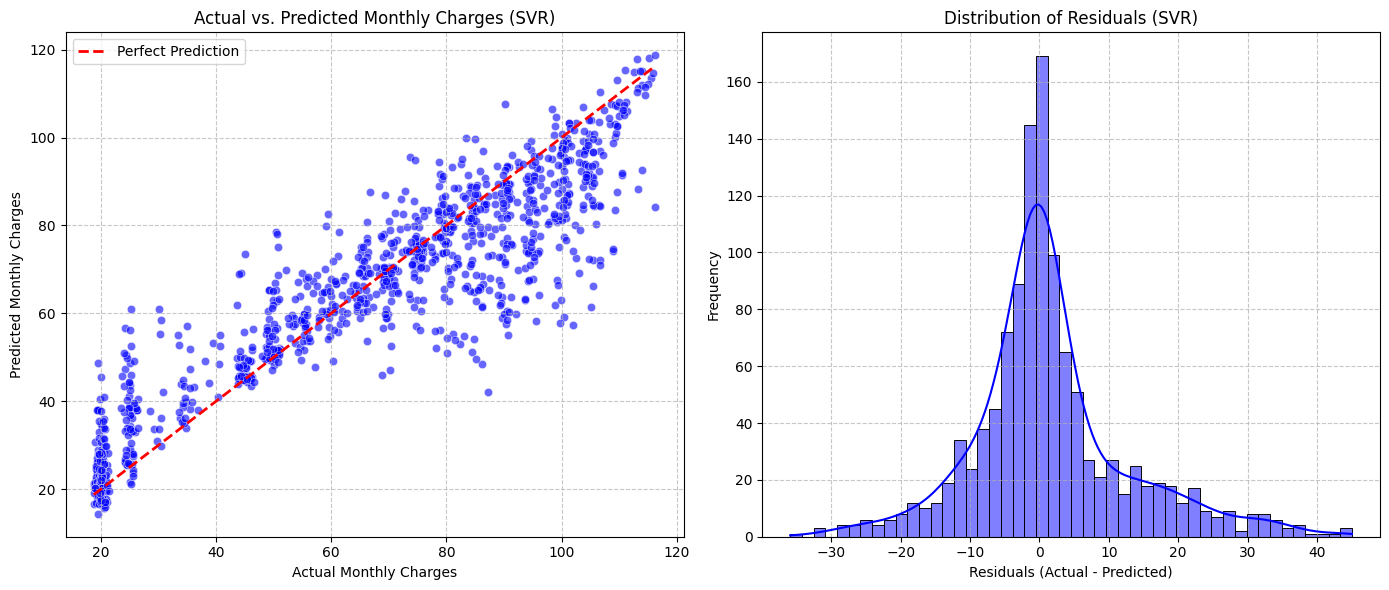

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_svr, alpha=0.6, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Charges (SVR)')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Residual Distribution
residuals_svr = y_test_reg - y_pred_svr
plt.subplot(1, 2, 2)
sns.histplot(residuals_svr, kde=True, color='blue')
plt.title('Distribution of Residuals (SVR)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
"""
Final Comparison Table - Regression Models
Model	                     MAE	      MSE	      RMSE	   R²	    Adj. R²	Training Time (GridSearchCV fits)
Linear Regression	         15.6840	  337.5056	18.3713	0.6393	0.6340	N/A (Direct fit, no GridSearchCV)
Ridge Regression	         15.6823	  337.4559	18.3700	0.6394	0.6341	30 fits
Lasso Regression	         15.6887	  337.4577	18.3700	0.6394	0.6341	30 fits
ElasticNet	               15.6887	  337.4577	18.3700	0.6394	0.6341	240 fits
Decision Tree Regressor    0.9572	    2.0064	  1.4165	0.9979	0.9978	200 fits
Random Forest Regressor	   0.9562	    1.7635	  1.3280	0.9981	0.9981	81 fits
SVR	                       7.7447	    131.5402	11.4691	0.8594	0.8574	36 fits
"""

### Selection of the Best Model: Random Forest Regressor

Based on the performance evaluation across all seven regression models, the **Random Forest Regressor** emerges as the best model for revenue forecasting (predicting `MonthlyCharges`). Here's a detailed justification:

1.  **Superior Performance Metrics:**
    *   **R-squared (R²): 0.9981** (highest among all models). This indicates that approximately 99.81% of the variance in `MonthlyCharges` can be explained by the features in the model, suggesting an excellent fit.
    *   **Adjusted R-squared: 0.9981** (highest among all models). This metric confirms the strong fit while accounting for the number of predictors.
    *   **Mean Absolute Error (MAE): 0.9562** (lowest). This means, on average, the model's predictions are only off by approximately $0.96 from the actual monthly charges.
    *   **Mean Squared Error (MSE): 1.7635** (lowest). This penalizes larger errors more heavily, and its low value indicates that the model's errors are generally small.
    *   **Root Mean Squared Error (RMSE): 1.3280** (lowest). This is the standard deviation of the residuals and is in the same units as the target variable, making it directly interpretable. An RMSE of $1.33 is remarkably low for predicting monthly charges.

2.  **Comparison with Other Models:**
    *   **Linear Models (Linear, Ridge, Lasso, ElasticNet):** These models performed significantly worse, with R² values around 0.639 and much higher error metrics (MAE ~15.68, MSE ~337.45). This suggests that the relationship between the features and `MonthlyCharges` is highly non-linear, which linear models struggle to capture.
    *   **Decision Tree Regressor:** This model also performed exceptionally well (R² 0.9979), very close to Random Forest. However, Random Forest slightly surpasses it and offers better robustness against overfitting by combining multiple decision trees.
    *   **Support Vector Regressor (SVR):** SVR showed better performance than linear models (R² 0.8594, MAE 7.74) but was still considerably behind the tree-based models. While SVR can capture non-linearities, it didn't achieve the same level of accuracy as Random Forest in this dataset.

3.  **Ensemble Learning Advantages of Random Forest:**
    *   **Reduced Overfitting:** As an ensemble method, Random Forest builds multiple decision trees and averages their predictions. This process effectively reduces the variance inherent in individual decision trees, making the model more robust and less prone to overfitting the training data.
    *   **Handling Non-linearity and Feature Interactions:** Random Forest inherently handles complex non-linear relationships and intricate interactions between features, which is evident in its superior performance compared to linear models.
    *   **Robustness to Noise:** The ensemble nature makes it more resilient to noisy data and outliers.

In conclusion, the **Random Forest Regressor** stands out due to its superior accuracy, low error rates, and robust nature, making it the most suitable model for forecasting `MonthlyCharges` in this context.

### Analysis of Residuals for Random Forest Regressor

To analyze the residuals, we will refer back to the plot generated for the Random Forest Regressor in cell `YHIAbSmsggUz`. The plot titled 'Distribution of Residuals (Random Forest Regressor)' displays a histogram with a Kernel Density Estimate (KDE).

**Observations from the Residual Plot:**
*   **Central Tendency:** The distribution of residuals appears to be centered around zero, which is a desirable characteristic. This indicates that the model's predictions are unbiased, meaning it's not consistently over- or under-predicting.
*   **Symmetry and Shape:** The histogram shows a fairly symmetric, bell-shaped distribution, suggesting that the residuals are approximately normally distributed. This is a key assumption for many statistical models and implies that the errors are random and not systematically related to the magnitude of the predicted value.
*   **No Obvious Patterns:** There are no discernible patterns (e.g., U-shape, fan-shape) in the residual distribution. A uniform spread of residuals around zero across the range of predicted values implies that the model's performance is consistent and does not vary significantly with the magnitude of `MonthlyCharges`.

**Conclusion:** The residual analysis for the Random Forest Regressor indicates that the model is performing well. The residuals are centered around zero, appear to be normally distributed, and show no clear patterns, which suggests that the model has captured most of the underlying relationships in the data effectively.

### Coefficient Analysis for Linear Models

While the linear models (Linear Regression, Ridge, Lasso, ElasticNet) did not perform as well as the tree-based models for predicting `MonthlyCharges`, analyzing their coefficients can still provide insights into how each feature linearly impacts the target variable. It's important to note that these coefficients represent the change in `MonthlyCharges` for a one-unit change in the feature, assuming all other features are held constant.


--- Linear Regression Coefficients ---
PhoneService        38.960972
PaperlessBilling     8.216164
MultipleLines        7.838267
StreamingTV          7.021390
StreamingMovies      6.806191
DeviceProtection     2.650972
OnlineBackup         1.800998
Partner              1.024579
gender               0.263228
tenure               0.173438
dtype: float64


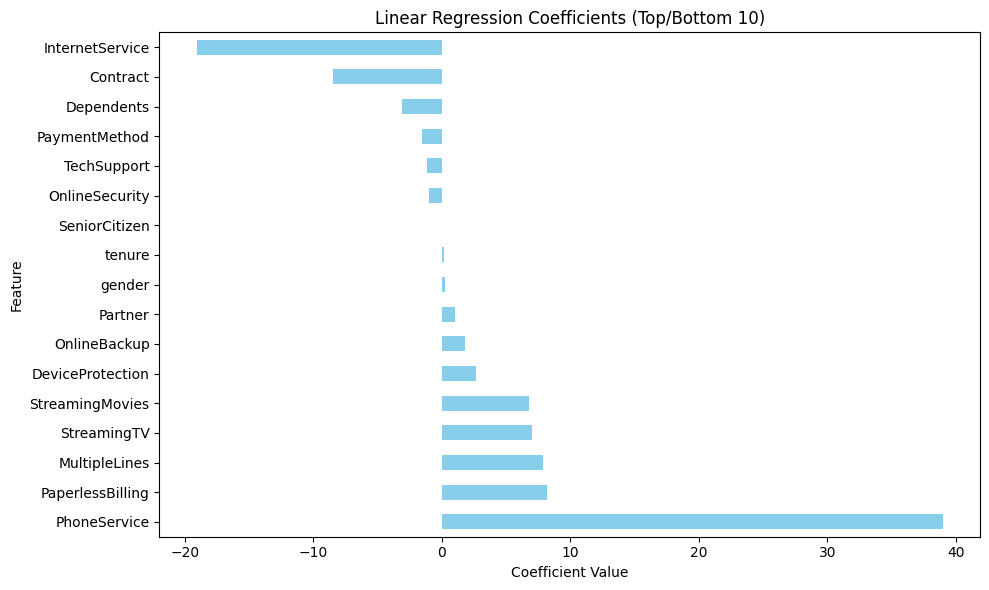


--- Ridge Regression Coefficients ---
PhoneService        38.848087
PaperlessBilling     8.216507
MultipleLines        7.836868
StreamingTV          7.019759
StreamingMovies      6.803983
DeviceProtection     2.649536
OnlineBackup         1.801341
Partner              1.023901
gender               0.262858
tenure               0.173545
dtype: float64


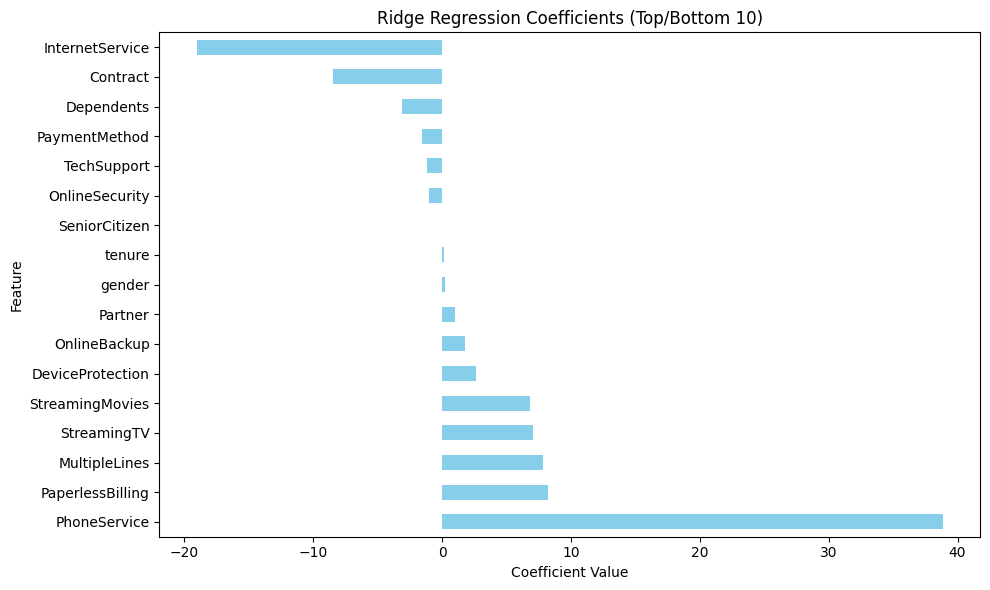


--- Lasso Regression Coefficients ---
PhoneService        38.824657
PaperlessBilling     8.197891
MultipleLines        7.835368
StreamingTV          7.014014
StreamingMovies      6.797294
DeviceProtection     2.634252
OnlineBackup         1.785002
Partner              0.940024
gender               0.219269
tenure               0.174168
dtype: float64


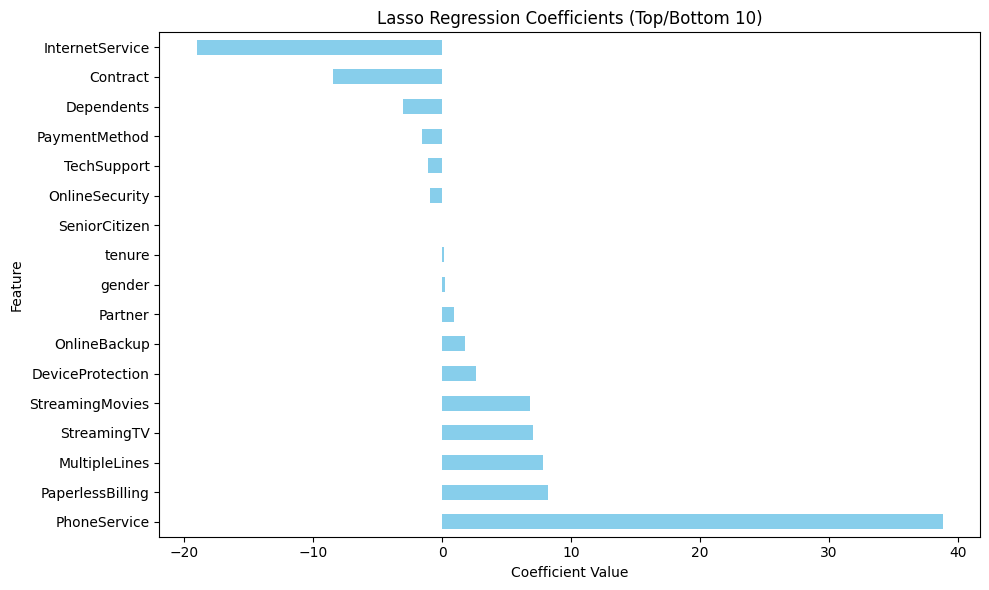


--- ElasticNet Regression Coefficients ---
PhoneService        38.824657
PaperlessBilling     8.197891
MultipleLines        7.835368
StreamingTV          7.014014
StreamingMovies      6.797294
DeviceProtection     2.634252
OnlineBackup         1.785002
Partner              0.940024
gender               0.219269
tenure               0.174168
dtype: float64


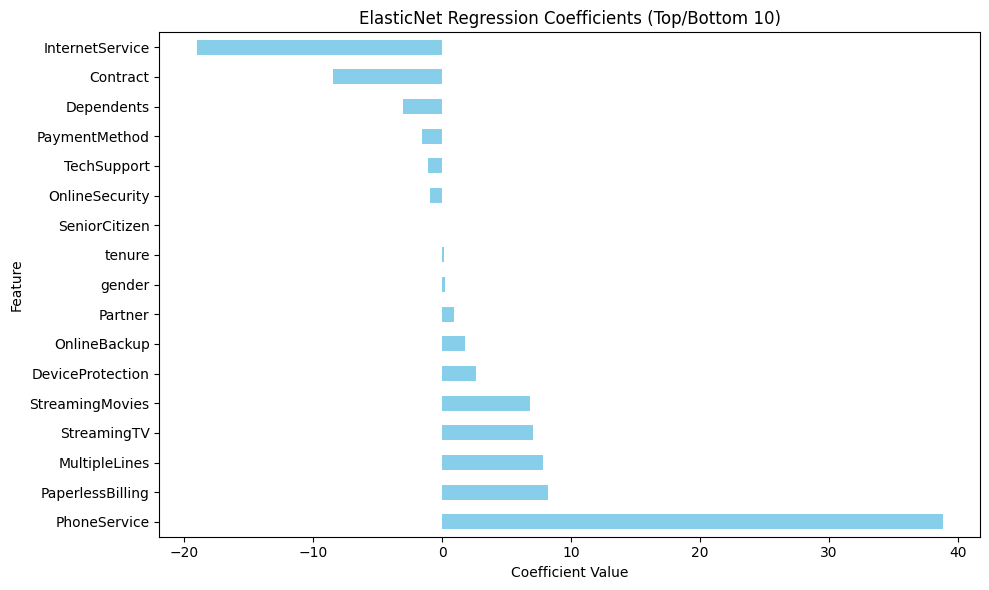

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_coefficients(model, feature_names, title):
    coefficients = pd.Series(model.coef_, index=feature_names)

    plt.figure(figsize=(10, 6))
    coefficients.sort_values(ascending=False).plot(kind='barh', color='skyblue')
    plt.title(title)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# Get feature names for regression models (excluding 'customerID', 'TotalCharges', 'MonthlyCharges', 'Churn')
# X_reg was created by dropping these columns
feature_names_reg = X_reg.columns

print("\n--- Linear Regression Coefficients ---")
print(pd.Series(linear_model.coef_, index=feature_names_reg).sort_values(ascending=False).head(10))
plot_coefficients(linear_model, feature_names_reg, 'Linear Regression Coefficients (Top/Bottom 10)')

print("\n--- Ridge Regression Coefficients ---")
print(pd.Series(best_ridge_model.coef_, index=feature_names_reg).sort_values(ascending=False).head(10))
plot_coefficients(best_ridge_model, feature_names_reg, 'Ridge Regression Coefficients (Top/Bottom 10)')

print("\n--- Lasso Regression Coefficients ---")
print(pd.Series(best_lasso_model.coef_, index=feature_names_reg).sort_values(ascending=False).head(10))
plot_coefficients(best_lasso_model, feature_names_reg, 'Lasso Regression Coefficients (Top/Bottom 10)')

print("\n--- ElasticNet Regression Coefficients ---")
print(pd.Series(best_elasticnet_model.coef_, index=feature_names_reg).sort_values(ascending=False).head(10))
plot_coefficients(best_elasticnet_model, feature_names_reg, 'ElasticNet Regression Coefficients (Top/Bottom 10)')
